# Dataset Exploration & Analysis
## ArtEmis - Affective Language for Visual Art
### COMP6001 - Computer Vision and Multimodal Machine Learning | Adelaide University

This notebook covers exploratory data analysis (EDA) of the ArtEmis dataset. We examine class distributions, artistic styles, annotation agreement, and visual characteristics to understand the data before modelling.

In [2]:
# Import
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

In [3]:
# Load Dataset
df = pd.read_csv("../data/dataset_final.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Shape: (49056, 8)

Columns: ['emotion', 'utterance', 'art_style', 'painting', 'anchor_art_style', 'anchor_painting', 'repetition', 'filename']

First few rows:


,emotion,utterance,art_style,painting,anchor_art_style,anchor_painting,repetition,filename
0,sadness,This painting shows a gloomy day. The darkness...,Realism,johan-hendrik-weissenbruch_windy-day,Realism,johan-hendrik-weissenbruch_ship-canal,1,johan-hendrik-weissenbruch_windy-day.jpg
1,sadness,the weather and atmosphere makes me feel sad,Romanticism,ivan-aivazovsky_landscape-with-a-schooner-1880,Realism,johan-hendrik-weissenbruch_ship-canal,45,ivan-aivazovsky_landscape-with-a-schooner-1880...
2,sadness,"Dark and moody, cloudy sky that is depressing",Impressionism,paul-gauguin_clearing-1873,Realism,johan-hendrik-weissenbruch_ship-canal,18,paul-gauguin_clearing-1873.jpg
3,sadness,the picture is dark with a somber tone,Impressionism,john-henry-twachtman_winter-landscape,Realism,johan-hendrik-weissenbruch_ships-in-harbour,7,john-henry-twachtman_winter-landscape.jpg
4,sadness,the dark colors make the painting look gloomy,Impressionism,eugene-boudin_trouville-the-port-1864,Realism,johan-hendrik-weissenbruch_ships-in-harbour,5,eugene-boudin_trouville-the-port-1864.jpg


In [4]:
# Basic Stats
print(df['emotion'].value_counts())
print(f"\nUnique paintings: {df['painting'].nunique()}")
print(f"Unique art styles: {df['art_style'].nunique()}")
print(f"Missing values:\n{df.isnull().sum()}")

emotion
sadness        18401
fear           11794
disgust         7252
contentment     4363
anger           3302
awe             1713
excitement      1369
amusement        862
Name: count, dtype: int64

Unique paintings: 49056
Unique art styles: 27
Missing values:
emotion             0
utterance           0
art_style           0
painting            0
anchor_art_style    0
anchor_painting     0
repetition          0
filename            0
dtype: int64


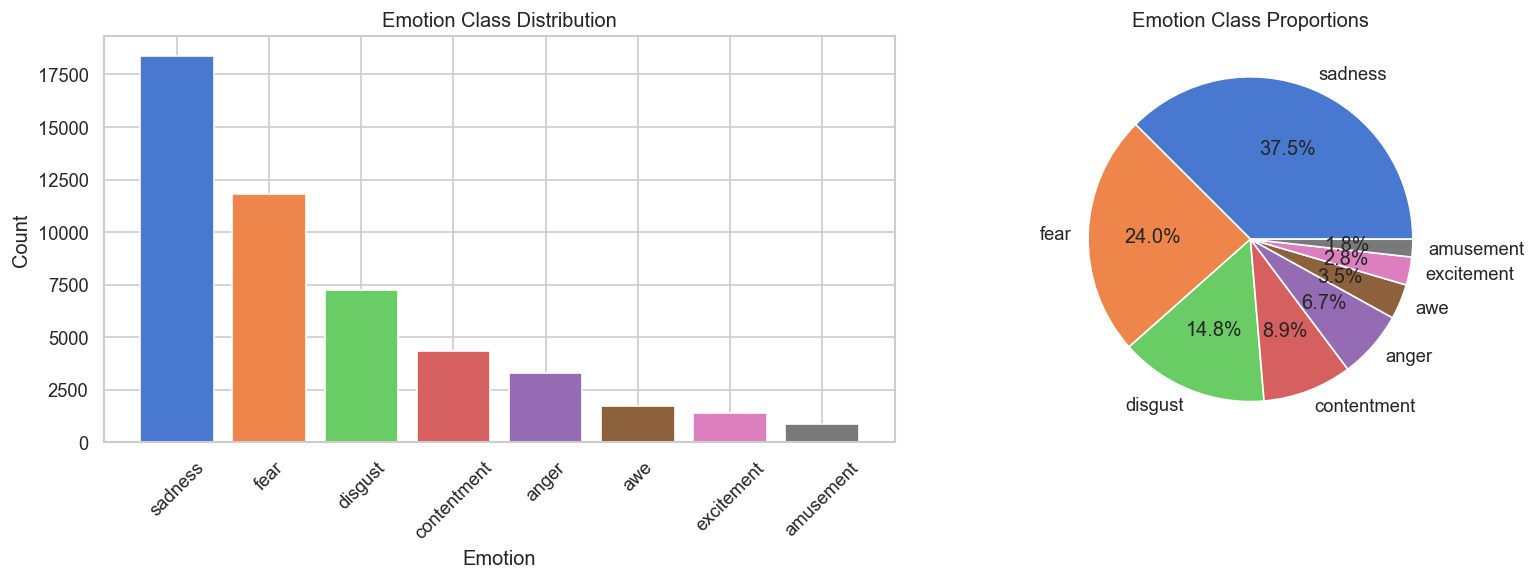

In [5]:
# Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
emotion_counts = df['emotion'].value_counts()
axes[0].bar(emotion_counts.index, emotion_counts.values, color=sns.color_palette("muted", len(emotion_counts)))
axes[0].set_title("Emotion Class Distribution")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', colors=sns.color_palette("muted", len(emotion_counts)))
axes[1].set_title("Emotion Class Proportions")

plt.tight_layout()
plt.savefig("../data/class_distribution.png")
plt.show()

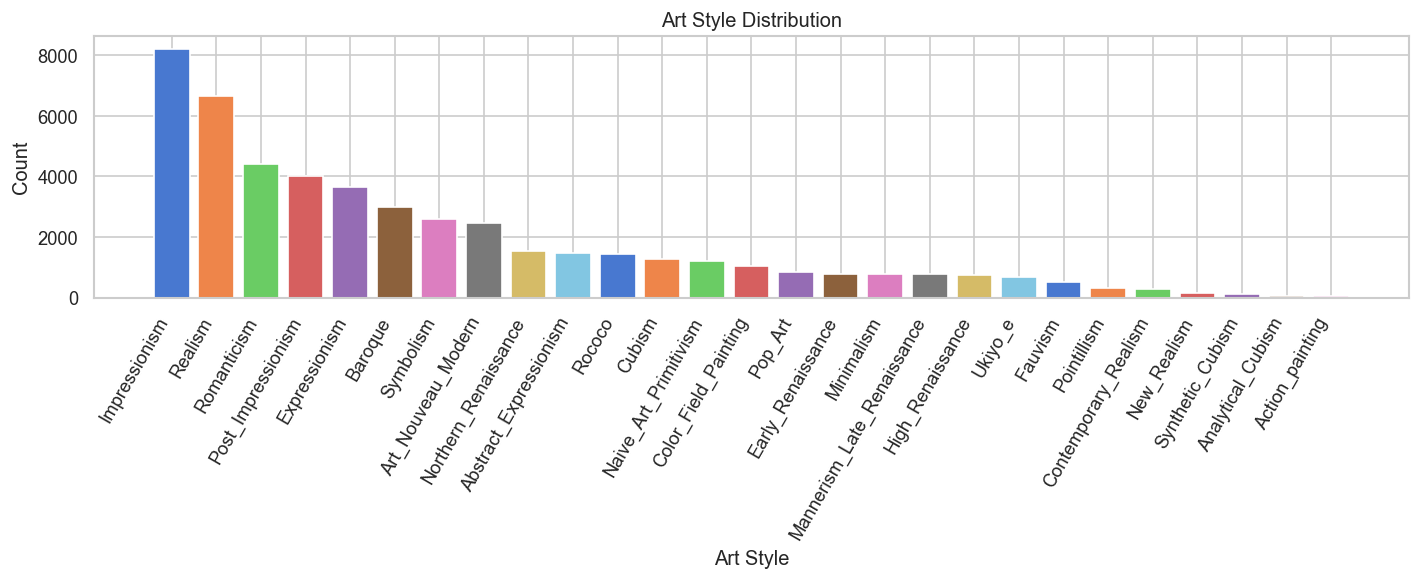

In [6]:
# Art Style Distribution
style_counts = df['art_style'].value_counts()

plt.figure(figsize=(12, 5))
plt.bar(style_counts.index, style_counts.values, color=sns.color_palette("muted", len(style_counts)))
plt.title("Art Style Distribution")
plt.xlabel("Art Style")
plt.ylabel("Count")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.savefig("../data/style_distribution.png")
plt.show()

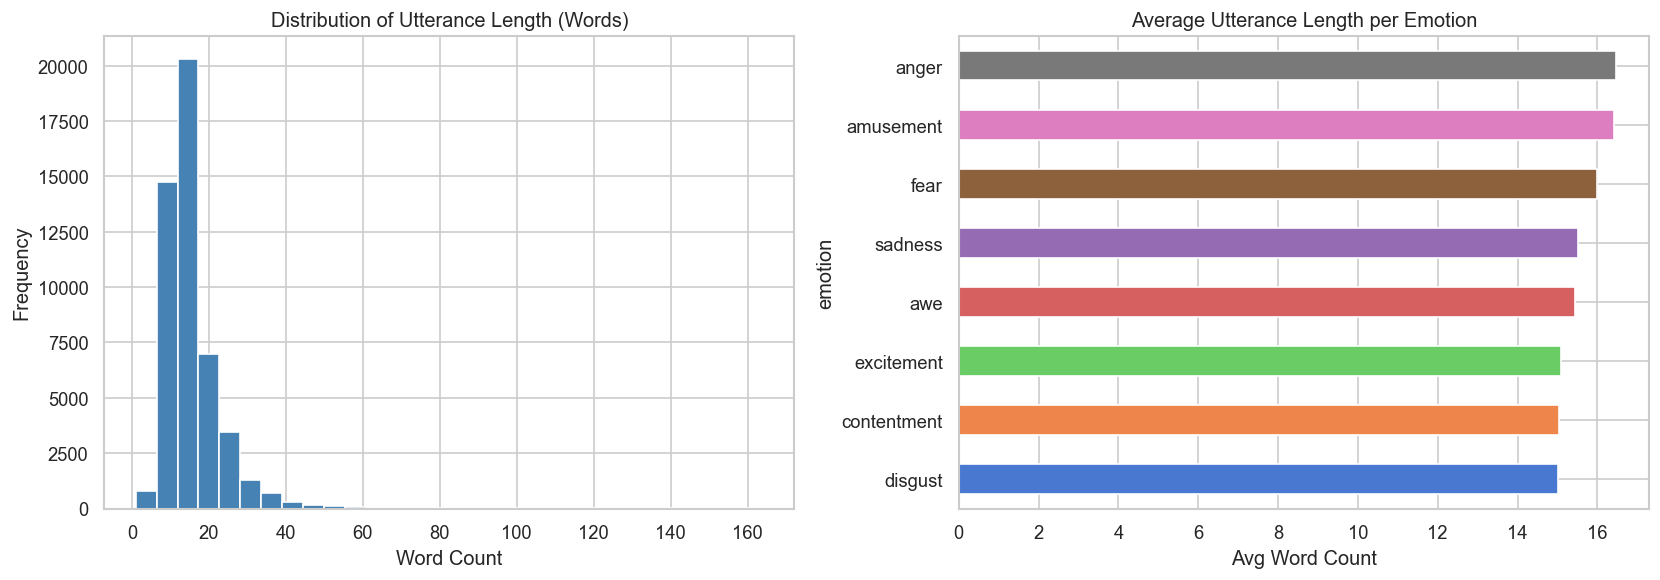

Average utterance length: 15.6 words
Max: 164 | Min: 1


In [7]:
# Utterance (Text) Analysis
df['utterance_length'] = df['utterance'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['utterance_length'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title("Distribution of Utterance Length (Words)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")

df.groupby('emotion')['utterance_length'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color=sns.color_palette("muted", 8)
)
axes[1].set_title("Average Utterance Length per Emotion")
axes[1].set_xlabel("Avg Word Count")

plt.tight_layout()
plt.savefig("../data/utterance_distribution.png")
plt.show()

print(f"Average utterance length: {df['utterance_length'].mean():.1f} words")
print(f"Max: {df['utterance_length'].max()} | Min: {df['utterance_length'].min()}")

## Dataset Summary

- 49,056 annotations across 49,056 unique paintings, 27 artistic styles
- **8 emotion classes** (this subset excludes "Something Else")
- **Severe class imbalance**: sadness (37.5%) vs amusement (1.8%) - 21x difference
- Requires class-weighted loss and F1-macro evaluation metric (not accuracy)
- **Multimodal**: each painting paired with a free-text rationale (~15.6 words avg)
- No missing values; clean dataset ready for modelling
- Impressionism dominates art styles (most represented in WikiArt)